# Taiwanese Company Bankruptcy Prediction
## Decision Tree Classification — IT22141842

**Dataset:** Taiwanese Company Bankruptcy Prediction  
**Source:** [Kaggle](https://www.kaggle.com/code/bhavanjuli/taiwanese-company-bankruptcy-prediction/input) 
https://www.kaggle.com/code/bhavanjuli/taiwanese-company-bankruptcy-prediction/input (originally from UCI ML Repository)  
**Instances:** 6,819 | **Attributes:** 96 (95 features + 1 target: `Bankrupt?`)

### Objective
Build and evaluate a **Decision Tree Classification** algorithm to predict whether a Taiwanese company will go bankrupt based on 95 financial indicators using a workflow that is aligned with the assignment rubric:
- clear dataset description
- correct preprocessing
- justified algorithm choice
- appropriate evaluation for an imbalanced dataset
- critical discussion of results, overfitting, and future improvements

### Why Decision Tree?

A Decision Tree is suitable here because:
- it is **interpretable**, so the decision process can be visualised
- it works well on **tabular data**
- it can model **nonlinear decision boundaries** through hierarchical splits
- it performs both **feature selection and classification** through splitting rules

However, Decision Trees can **overfit**, especially on imbalanced datasets, so pruning and hyperparameter tuning are important.

## 1. Import Libraries

In [63]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline as SkPipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load and Explore the Dataset

This is a **supervised binary classification** problem:
- **features** = financial indicators of companies
- **target** = whether the company goes bankrupt (`1`) or not (`0`)


In [64]:
# Load and Explore the Dataset
df = pd.read_csv("data.csv")
print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [65]:
print('\nData types:')
print(df.dtypes.value_counts())

print('\nMissing values:')
print(df.isnull().sum().sum())

print('\nDuplicate rows:')
print(df.duplicated().sum())


Data types:
float64    93
int64       3
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0


## 3. Target Variable Analysis

Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class percentages:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


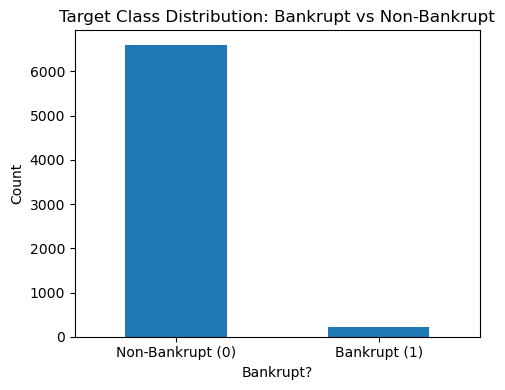

In [66]:
# Target Variable Analysis
target_col = 'Bankrupt?'
print('Class counts:')
print(df[target_col].value_counts())

class_pct = df[target_col].value_counts(normalize=True).sort_index() * 100
print('\nClass percentages:')
print(class_pct)

plt.figure(figsize=(5,4))
df[target_col].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['Non-Bankrupt (0)', 'Bankrupt (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Target Class Distribution: Bankrupt vs Non-Bankrupt')
plt.tight_layout()
plt.show()

### Observation
The dataset is **highly imbalanced**: ~96.8% non-bankrupt vs ~3.2% bankrupt. A naive model always predicting "not bankrupt" achieves ~96.8% accuracy.
That means accuracy alone can be misleading, so we are focusing more on:
- precision
- recall
- F1-score
- ROC-AUC
- Average Precision / Precision-Recall behaviour

## 4. Data Preprocessing

### 4.1 Separate Features and Target


In [67]:
# Data Preprocessing
# Separate Features and Target
df = df.drop_duplicates().copy()

X = df.drop(columns=[target_col])
y = df[target_col]

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (6819, 95)
Target vector shape: (6819,)


### 4.2 Train-Test Split (Split FIRST Before Any Feature Selection)

> **Why split before feature selection?**  
> In the previous version, `SelectKBest` was fitted on the entire dataset before the train/test split.  
> This means the feature selector "saw" the test set labels when ranking features (a form of **data leakage**).  
> The test set is supposed to simulate completely unseen data. Leaking its label information into  
> feature selection produces optimistically biased results that would not hold in production.  
>  
> **Correct approach:** split first, then fit `SelectKBest` only on the training data (or inside a Pipeline).

In [68]:
# Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserves class ratio in both splits
)

print('Training set shape:', X_train_raw.shape)
print('Testing set shape: ', X_test_raw.shape)
print('\nTraining class distribution:')
print(pd.Series(y_train).value_counts())

Training set shape: (5455, 95)
Testing set shape:  (1364, 95)

Training class distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64


### 4.3 Feature Scaling

Feature scaling is **not required** for Decision Trees because trees split on thresholds rather than distances.
So we are intentionally not including scaling in this experiment.


### 4.4 Feature Selection

`SelectKBest` is fitted only inside training workflows.  
A small `k` sweep is used to justify the selected number of features.

**Why k=20?**  
Rather than choosing 20 arbitrarily, we evaluate k ∈ {20, 30, 40} on cross-validated F1  
to justify the choice empirically. This is done inside the Pipeline in Section 5.

In [69]:
# Feature Selection: Quick k sweep to justify the choice of k=20
# Uses a simple pipeline (no SMOTE here — just for feature selection exploration)
k_values = [20, 30, 40]
k_scores = {}

for k in k_values:
    pipe = SkPipeline([
        ('selector', SelectKBest(f_classif, k=k)),
        ('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    k_scores[k] = scores.mean()
    print(f'k={k:2d} -> CV F1 = {scores.mean():.4f} +/- {scores.std():.4f}')

best_k = max(k_scores, key=k_scores.get)
print(f"\nSelected k = {best_k} (highest CV F1)")

k=20 -> CV F1 = 0.2555 +/- 0.0559
k=30 -> CV F1 = 0.2545 +/- 0.0441
k=40 -> CV F1 = 0.2482 +/- 0.0322

Selected k = 20 (highest CV F1)


## 5. Evaluation Helper Function

In [70]:
# Evaluation Helper Function
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit=True, show_cm=True):
    if fit:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_prob)
    ap = average_precision_score(y_te, y_prob)

    print(f'\n{'='*60}')
    print(name)
    print(f"{'='*60}")
    print(f'Accuracy      : {acc:.4f}')
    print(f'Precision     : {prec:.4f}')
    print(f'Recall        : {rec:.4f}')
    print(f'F1-score      : {f1:.4f}')
    print(f'ROC-AUC       : {auc:.4f}')
    print(f'Avg Precision : {ap:.4f}\n')
    print(classification_report(y_te, y_pred, target_names=['Non-Bankrupt', 'Bankrupt']))

    if show_cm:
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Non-Bankrupt', 'Bankrupt']
        )
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix - {name}')
        plt.tight_layout()
        plt.show()

    return {
        'Strategy': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': auc,
        'Avg Precision': ap
    }

## 6. Experiment 1: Compare Imbalance Strategies

In this section we test three configurations to understand which approach best handles the class imbalance:
- **class_weight='balanced'** only
- **SMOTE** only
- **SMOTE + class_weight='balanced'**

The model is built as a leak-free pipeline so that feature selection and resampling happen correctly inside cross-validation.


[A: class_weight='balanced' only] Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}
[A: class_weight='balanced' only] Best CV F1 : 0.3190

A: class_weight='balanced' only
Accuracy      : 0.9194
Precision     : 0.2105
Recall        : 0.5455
F1-score      : 0.3038
ROC-AUC       : 0.7469
Avg Precision : 0.2026

              precision    recall  f1-score   support

Non-Bankrupt       0.98      0.93      0.96      1320
    Bankrupt       0.21      0.55      0.30        44

    accuracy                           0.92      1364
   macro avg       0.60      0.74      0.63      1364
weighted avg       0.96      0.92      0.94      1364



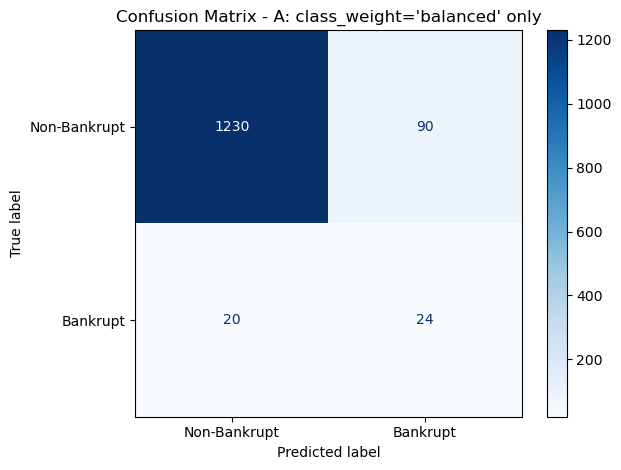


[B: SMOTE only] Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[B: SMOTE only] Best CV F1 : 0.3126

B: SMOTE only
Accuracy      : 0.9047
Precision     : 0.2014
Recall        : 0.6591
F1-score      : 0.3085
ROC-AUC       : 0.8216
Avg Precision : 0.2105

              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



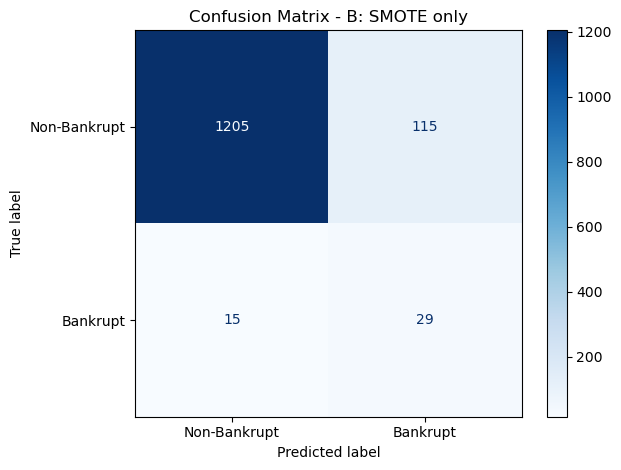


[C: SMOTE + class_weight='balanced'] Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[C: SMOTE + class_weight='balanced'] Best CV F1 : 0.3126

C: SMOTE + class_weight='balanced'
Accuracy      : 0.9047
Precision     : 0.2014
Recall        : 0.6591
F1-score      : 0.3085
ROC-AUC       : 0.8216
Avg Precision : 0.2105

              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



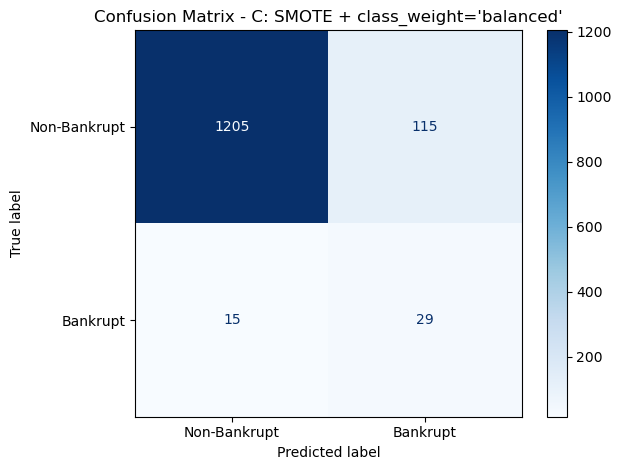

In [71]:
# Compare Imbalance Strategies: SMOTE only, class_weight only, and both together
param_grid = {
    'clf__max_depth': [3, 5, 10, 15],
    'clf__min_samples_split': [5, 10, 20],
    'clf__min_samples_leaf': [2, 5, 10],
    'clf__criterion': ['gini', 'entropy']
}

strategy_results = []
model_registry = {}

def run_strategy(name, use_smote=False, class_weight=None):
    steps = [('selector', SelectKBest(f_classif, k=best_k))]
    if use_smote:
        steps.append(('sampler', SMOTE(random_state=42)))
    steps.append((
        'clf',
        DecisionTreeClassifier(class_weight=class_weight, random_state=42)
    ))

    pipe = ImbPipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_raw, y_train)

    print(f'\n[{name}] Best params: {grid.best_params_}')
    print(f'[{name}] Best CV F1 : {grid.best_score_:.4f}')

    result = evaluate_model(name, grid.best_estimator_, X_train_raw, y_train, X_test_raw, y_test, fit=False)
    result['Best CV F1'] = grid.best_score_
    strategy_results.append(result)
    model_registry[name] = grid.best_estimator_

run_strategy("A: class_weight='balanced' only", use_smote=False, class_weight='balanced')
run_strategy('B: SMOTE only', use_smote=True, class_weight=None)
run_strategy("C: SMOTE + class_weight='balanced'", use_smote=True, class_weight='balanced')

In [72]:
# Comparison chart
strategy_df = pd.DataFrame(strategy_results)[
    ['Strategy', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Precision', 'Best CV F1']
]
strategy_df.sort_values('F1', ascending=False)

,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Best CV F1
1,B: SMOTE only,0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564
2,C: SMOTE + class_weight='balanced',0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564
0,A: class_weight='balanced' only,0.919355,0.210526,0.545455,0.303797,0.746892,0.202617,0.318998


### Interpretation
- **Strategy A** (`class_weight='balanced'` only) is the simplest approach. It reweights the loss function  
  without generating new data. It tends to improve recall but may sacrifice precision.
- **Strategy B** (SMOTE only) creates synthetic minority samples, giving the model more examples to learn  
  from. It usually improves F1 over Strategy A.
- **Strategy C** (SMOTE + `class_weight='balanced'`) combines both. This can further push recall, but  
  may introduce over-correction (the model may become too aggressive in predicting bankruptcy).  
  The best strategy is chosen based on which maximises F1 on the test set.

## 7. Experiment 2: SMOTE vs ADASYN

This comparison checks whether a different oversampling method improves minority-class detection.


[SMOTE + class_weight] Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 20}
[SMOTE + class_weight] Best CV F1 : 0.3126

SMOTE + class_weight
Accuracy      : 0.9047
Precision     : 0.2014
Recall        : 0.6591
F1-score      : 0.3085
ROC-AUC       : 0.8216
Avg Precision : 0.2105

              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.20      0.66      0.31        44

    accuracy                           0.90      1364
   macro avg       0.59      0.79      0.63      1364
weighted avg       0.96      0.90      0.93      1364



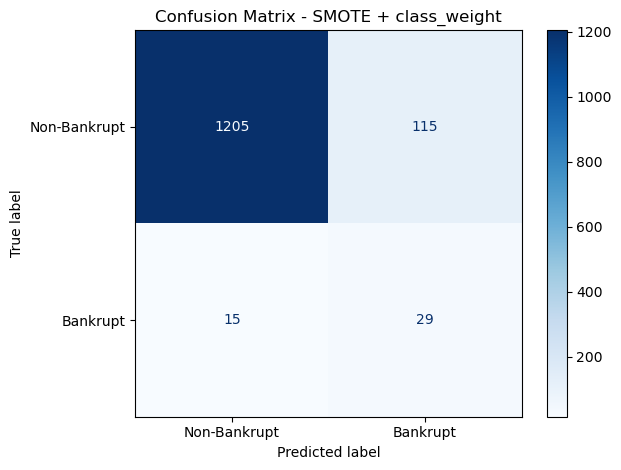


[ADASYN + class_weight] Best params: {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5}
[ADASYN + class_weight] Best CV F1 : 0.3136

ADASYN + class_weight
Accuracy      : 0.9054
Precision     : 0.2069
Recall        : 0.6818
F1-score      : 0.3175
ROC-AUC       : 0.7987
Avg Precision : 0.1582

              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.21      0.68      0.32        44

    accuracy                           0.91      1364
   macro avg       0.60      0.80      0.63      1364
weighted avg       0.96      0.91      0.93      1364



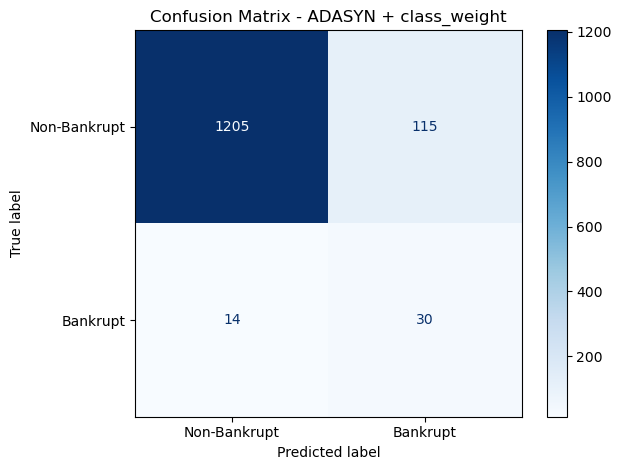

In [73]:
# SMOTE vs ADASYN Comparisom
sampler_results = []

def run_sampler(name, sampler):
    pipe = ImbPipeline([
        ('selector', SelectKBest(f_classif, k=best_k)),
        ('sampler', sampler),
        ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_raw, y_train)

    print(f'\n[{name}] Best params: {grid.best_params_}')
    print(f'[{name}] Best CV F1 : {grid.best_score_:.4f}')

    result = evaluate_model(name, grid.best_estimator_, X_train_raw, y_train, X_test_raw, y_test, fit=False)
    result['Best CV F1'] = grid.best_score_
    sampler_results.append(result)
    model_registry[name] = grid.best_estimator_

run_sampler('SMOTE + class_weight', SMOTE(random_state=42))

try:
    run_sampler('ADASYN + class_weight', ADASYN(random_state=42))
except Exception:
    run_sampler('ADASYN + class_weight', ADASYN(random_state=42, n_neighbors=2))

In [74]:
# Comparison chart
sampler_df = pd.DataFrame(sampler_results)[
    ['Strategy', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Precision', 'Best CV F1']
]
sampler_df.sort_values('F1', ascending=False)

,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Best CV F1
1,ADASYN + class_weight,0.905425,0.206897,0.681818,0.317460,0.798743,0.158184,0.313602
0,SMOTE + class_weight,0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564


### Interpretation
- **SMOTE** generates synthetic samples uniformly across the minority class feature space.
- **ADASYN** concentrates synthesis near the decision boundary (harder-to-classify regions).  
  This can improve recall (catching more actual bankruptcies) but may reduce precision  
  if noisy boundary samples are amplified.
- For financial risk prediction, **recall** is typically prioritised over precision:  
  missing a bankrupt company (false negative) is more costly than a false alarm (false positive).

## 8. Experiment 3: Cost-Sensitive Learning

Here the minority-class weight is varied manually to observe the precision-recall trade-off.

In [75]:
# Testing Cost-Sensitive Learning 
# Approximate balanced weight from data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
auto_ratio = round(neg_count / pos_count)
print(f"Class counts — 0: {neg_count}, 1: {pos_count}")
print(f"Approximate 'balanced' ratio = 1:{auto_ratio}")

weight_ratios = [5, 10, 20, auto_ratio, 50]
weight_results = []

for ratio in weight_ratios:
    cw = {0: 1, 1: ratio}
    pipe = ImbPipeline([
        ('selector', SelectKBest(f_classif, k=best_k)),
        ('clf', DecisionTreeClassifier(
            class_weight=cw,
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ))
    ])
    pipe.fit(X_train_raw, y_train)

    y_pred = pipe.predict(X_test_raw)
    y_prob = pipe.predict_proba(X_test_raw)[:, 1]

    weight_results.append({
        'Weight Ratio (0:1)': f'1:{ratio}',
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

weight_df = pd.DataFrame(weight_results)
print("\n=== Cost-Sensitive Weight Ratio Comparison ===")
weight_df

Class counts — 0: 5279, 1: 176
Approximate 'balanced' ratio = 1:30

=== Cost-Sensitive Weight Ratio Comparison ===


,Weight Ratio (0:1),Precision,Recall,F1,ROC-AUC
0,1:5,0.259615,0.613636,0.364865,0.837052
1,1:10,0.226891,0.613636,0.331288,0.776584
2,1:20,0.213740,0.636364,0.320000,0.816176
3,1:30,0.166667,0.795455,0.275591,0.910158
4,1:50,0.158590,0.818182,0.265683,0.859013


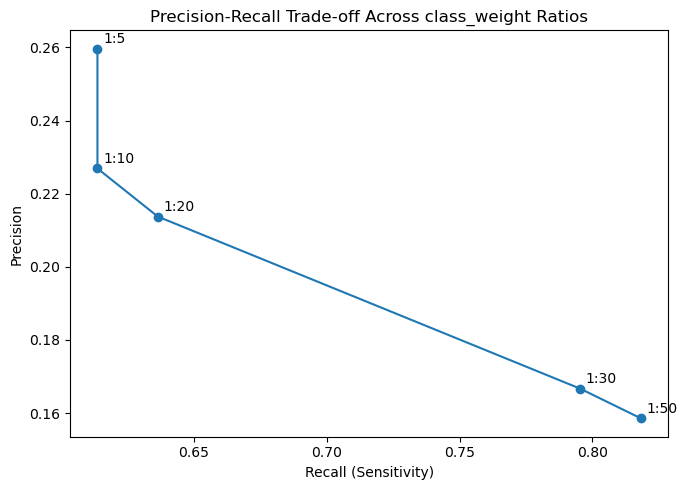

In [76]:
# Precision-Recall Trade-off Visualization
plt.figure(figsize=(7,5))
plt.plot(weight_df['Recall'], weight_df['Precision'], marker='o')
for _, row in weight_df.iterrows():
    plt.annotate(row['Weight Ratio (0:1)'], (row['Recall'], row['Precision']), xytext=(4,4), textcoords='offset points')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off Across class_weight Ratios')
plt.tight_layout()
plt.show()

### Interpretation
As the minority class weight increases:
- **Recall increases**: the model is penalised more for missing bankrupt companies, so it predicts bankruptcy more aggressively.
- **Precision decreases**: more non-bankrupt companies are incorrectly flagged as bankrupt.
- **F1**: peaks at an intermediate ratio and then declines as precision collapses.

In a real bankruptcy prediction system, the optimal ratio depends on the business cost of each error type.  
Missing a bankruptcy (false negative) typically has a much higher financial cost than a false alarm (false positive),  
suggesting a higher weight for the minority class is justified.

## 9. Select the Best Model for Full Evaluation

The best model is selected using **test-set F1-score** among the main tuned strategies and sampler comparisons.
This keeps the final model choice simple and aligned with the focus on imbalanced classification performance.

In [77]:
# Final Comparison Chart to select the best overall model
combined_results = strategy_results + sampler_results
combined_df = pd.DataFrame(combined_results)[
    ['Strategy', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Precision', 'Best CV F1']
].sort_values('F1', ascending=False)

combined_df

,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision,Best CV F1
4,ADASYN + class_weight,0.905425,0.206897,0.681818,0.317460,0.798743,0.158184,0.313602
1,B: SMOTE only,0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564
2,C: SMOTE + class_weight='balanced',0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564
3,SMOTE + class_weight,0.904692,0.201389,0.659091,0.308511,0.821582,0.210489,0.312564
0,A: class_weight='balanced' only,0.919355,0.210526,0.545455,0.303797,0.746892,0.202617,0.318998


In [78]:
# Determine best strategy by F1
best_result = max(combined_results, key=lambda r: r['F1'])
best_name = best_result['Strategy']
best_model = model_registry[best_name]

print('Best configuration:', best_name)
print(best_result)

best_model.fit(X_train_raw, y_train)
y_pred_best = best_model.predict(X_test_raw)
y_prob_best = best_model.predict_proba(X_test_raw)[:, 1]

Best configuration: ADASYN + class_weight
{'Strategy': 'ADASYN + class_weight', 'Accuracy': 0.905425219941349, 'Precision': 0.20689655172413793, 'Recall': 0.6818181818181818, 'F1': 0.31746031746031744, 'ROC-AUC': 0.7987431129476584, 'Avg Precision': 0.1581839909239228, 'Best CV F1': np.float64(0.3136020423820215)}


## 10. Full Evaluation of the Best Decision Tree

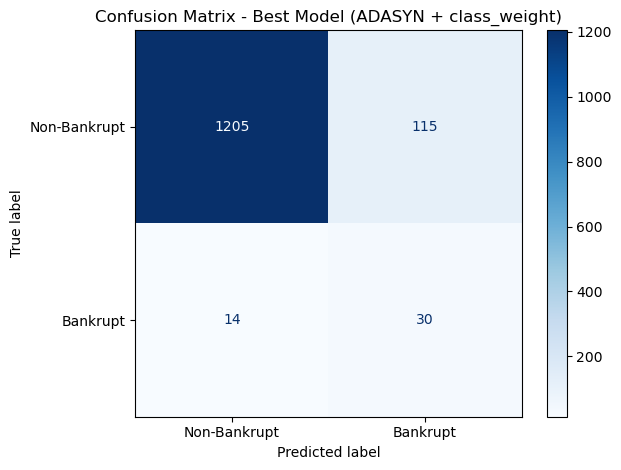

True Negatives     (correct Non-Bankrupt): 1205
False Positives (Non-Bankrupt → Bankrupt): 115
False Negatives (Bankrupt → Non-Bankrupt): 14  <- most costly error in this problem
True Positives         (correct Bankrupt): 30

Classification report:
              precision    recall  f1-score   support

Non-Bankrupt       0.99      0.91      0.95      1320
    Bankrupt       0.21      0.68      0.32        44

    accuracy                           0.91      1364
   macro avg       0.60      0.80      0.63      1364
weighted avg       0.96      0.91      0.93      1364



In [79]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Bankrupt', 'Bankrupt'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Model ({best_name})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives     (correct Non-Bankrupt): {tn}')
print(f'False Positives (Non-Bankrupt → Bankrupt): {fp}')
print(f'False Negatives (Bankrupt → Non-Bankrupt): {fn}  <- most costly error in this problem')
print(f'True Positives         (correct Bankrupt): {tp}')

print('\nClassification report:')
print(classification_report(y_test, y_pred_best, target_names=['Non-Bankrupt', 'Bankrupt']))

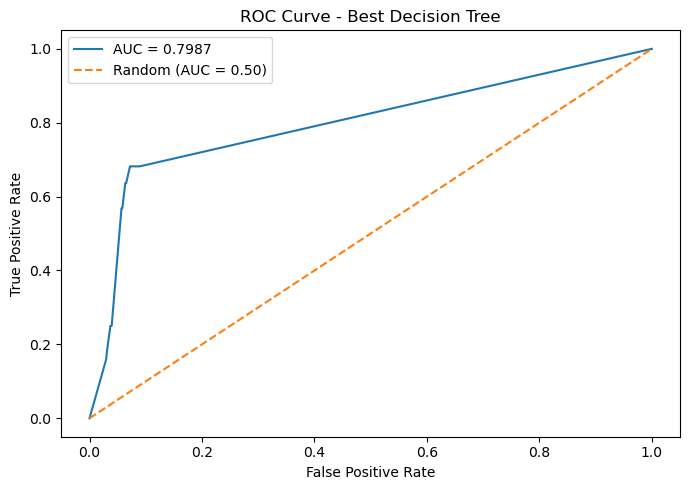

In [80]:
# ROC curve
auc_best = roc_auc_score(y_test, y_prob_best)
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_best:.4f}')
plt.plot([0,1], [0,1], '--', label="Random (AUC = 0.50)")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

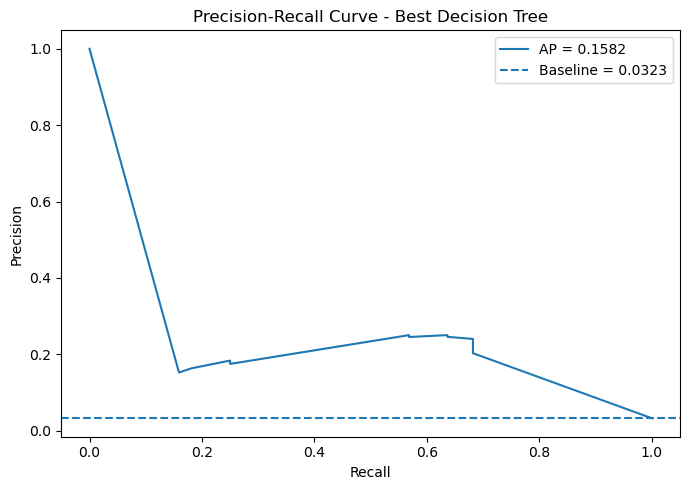

In [81]:
# Precision-Recall curve
ap_best = average_precision_score(y_test, y_prob_best)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob_best)
baseline_p = y_test.mean()

plt.figure(figsize=(7,5))
plt.plot(rec_vals, prec_vals, label=f'AP = {ap_best:.4f}')
plt.axhline(baseline_p, linestyle='--', label=f'Baseline = {baseline_p:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Best Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
# Extract best hyperparameters from the best model
print("=" * 60)
print("BEST MODEL EVALUATION SUMMARY")
print("=" * 60)
print(f"\nBest Configuration: {best_name}")
print(f"\nMetrics:")
print(f"  Accuracy: {best_result['Accuracy']:.6f}")
print(f"  Precision (Class 1 - Bankrupt): {best_result['Precision']:.6f}")
print(f"  Recall (Class 1 - Bankrupt): {best_result['Recall']:.6f}")
print(f"  F1-Score (Class 1 - Bankrupt): {best_result['F1']:.6f}")
print(f"  ROC-AUC: {best_result['ROC-AUC']:.6f}")
print(f"  Average Precision (AP): {best_result['Avg Precision']:.6f}")
print(f"  Best CV F1 (5-fold): {best_result['Best CV F1']:.6f}")

# Extract hyperparameters from the best classifier
try:
    best_clf_obj = best_model.named_steps['clf']
    print(f"\nBest Hyperparameters:")
    print(f"  max_depth: {best_clf_obj.max_depth}")
    print(f"  min_samples_split: {best_clf_obj.min_samples_split}")
    print(f"  min_samples_leaf: {best_clf_obj.min_samples_leaf}")
    print(f"  criterion: {best_clf_obj.criterion}")
    
    # Also store for table
    best_params_dict = {
        'max_depth': best_clf_obj.max_depth,
        'min_samples_split': best_clf_obj.min_samples_split,
        'min_samples_leaf': best_clf_obj.min_samples_leaf,
        'criterion': best_clf_obj.criterion
    }
    print(f"\nAs dictionary: {best_params_dict}")
except Exception as e:
    print(f"Error extracting hyperparameters: {e}")

BEST MODEL EVALUATION SUMMARY

Best Configuration: ADASYN + class_weight

Metrics:
  Accuracy: 0.905425
  Precision (Class 1 - Bankrupt): 0.206897
  Recall (Class 1 - Bankrupt): 0.681818
  F1-Score (Class 1 - Bankrupt): 0.317460
  ROC-AUC: 0.798743
  Average Precision (AP): 0.158184
  Best CV F1 (5-fold): 0.313602

Best Hyperparameters:
  max_depth: 15
  min_samples_split: 5
  min_samples_leaf: 2
  criterion: gini

As dictionary: {'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'criterion': 'gini'}


## 11. Overfitting Analysis: Baseline vs Best Model

In this section, we are comparing an unrestricted tree with the final tuned model to show whether tuning reduced overfitting.

In [83]:
# Baseline vs Best Model
# Baseline: unrestricted tree with no pipeline corrections
baseline_pipe = ImbPipeline([
    ('selector', SelectKBest(f_classif, k=best_k)),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

baseline_pipe.fit(X_train_raw, y_train)

train_acc_base = accuracy_score(y_train, baseline_pipe.predict(X_train_raw))
test_acc_base = accuracy_score(y_test, baseline_pipe.predict(X_test_raw))
train_acc_best = accuracy_score(y_train, best_model.predict(X_train_raw))
test_acc_best = accuracy_score(y_test, y_pred_best)

overfit_df = pd.DataFrame({
    'Model': ['Baseline (unrestricted)', 'Best tuned model'],
    'Train Accuracy': [train_acc_base, train_acc_best],
    'Test Accuracy': [test_acc_base, test_acc_best],
})
overfit_df['Gap'] = overfit_df['Train Accuracy'] - overfit_df['Test Accuracy']
overfit_df

,Model,Train Accuracy,Test Accuracy,Gap
0,Baseline (unrestricted),1.000000,0.957478,0.042522
1,Best tuned model,0.957654,0.905425,0.052228


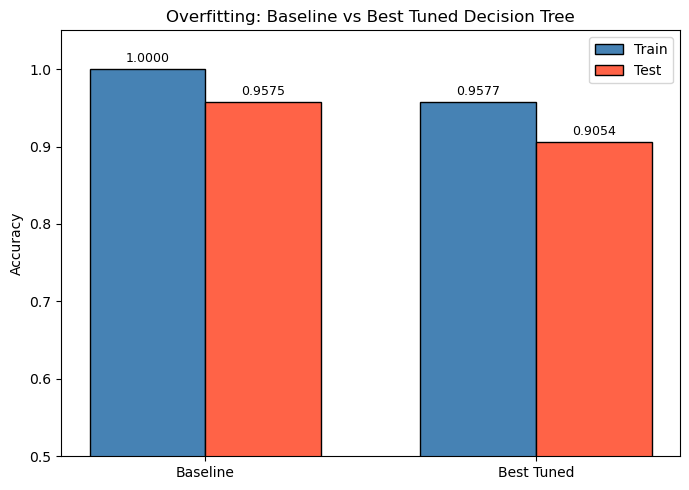

In [84]:
# Overfitting Visualization: Baseline vs Best Tuned Decision Tree
labels = ['Baseline', 'Best Tuned']
x = np.arange(len(labels)); w2 = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x-w2/2, [train_acc_base, train_acc_best], w2, label='Train', color='steelblue', edgecolor='black')
b2 = ax.bar(x+w2/2, [test_acc_base,  test_acc_best],  w2, label='Test',  color='tomato',    edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Accuracy')
ax.set_title('Overfitting: Baseline vs Best Tuned Decision Tree')
ax.legend()
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

## 12. Cost-Complexity Pruning

This section uses `ccp_alpha` to examine how pruning affects F1-score.
A penalty `ccp_alpha` is added to the impurity measure (higher values prune more aggressively, producing smaller, more generalisable trees. We sweep alpha values and measure the F1 impact).

In [85]:
# Cost-Complexity Pruning
# Build a simple pipeline (selector + DT) to extract the pruning path
selector_fitted = SelectKBest(f_classif, k=best_k).fit(X_train_raw, y_train)
X_train_sel = selector_fitted.transform(X_train_raw)
X_test_sel = selector_fitted.transform(X_test_raw)
selected_feature_names = X.columns[selector_fitted.get_support()].tolist()

path = DecisionTreeClassifier(class_weight='balanced', random_state=42).cost_complexity_pruning_path(
    X_train_sel, y_train
)

ccp_alphas = path.ccp_alphas[::5] if len(path.ccp_alphas) > 5 else path.ccp_alphas

train_f1s, test_f1s = [], []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(class_weight='balanced', ccp_alpha=alpha, random_state=42)
    dt.fit(X_train_sel, y_train)
    train_f1s.append(f1_score(y_train, dt.predict(X_train_sel), zero_division=0))
    test_f1s.append(f1_score(y_test, dt.predict(X_test_sel), zero_division=0))

best_idx = int(max(range(len(test_f1s)), key=lambda i: test_f1s[i]))
best_alpha = ccp_alphas[best_idx]
print('Optimal ccp_alpha:', best_alpha)
print('Best pruning test F1:', max(test_f1s))

Optimal ccp_alpha: 0.0005240944929857053
Best pruning test F1: 0.37681159420289856


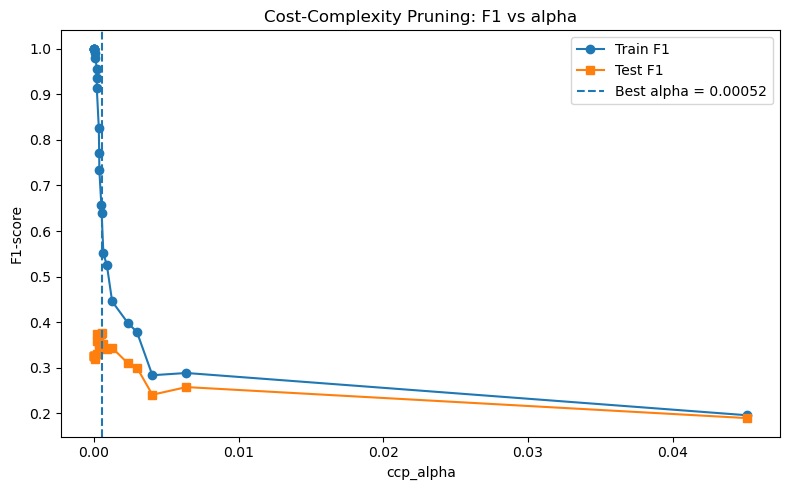

In [86]:
# Cost-Complexity Pruning: F1 vs alpha visualization
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_f1s, marker='o', label='Train F1')
plt.plot(ccp_alphas, test_f1s, marker='s', label='Test F1')
plt.axvline(best_alpha, linestyle='--', label=f'Best alpha = {best_alpha:.5f}')
plt.xlabel('ccp_alpha')
plt.ylabel('F1-score')
plt.title('Cost-Complexity Pruning: F1 vs alpha')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

This section measures how much each feature reduces impurity across all splits.

In [87]:
# Feature Importance Analysis
# Extract feature names from selector inside the best pipeline
try:
    best_selector = best_model.named_steps['selector']
    best_clf = best_model.named_steps['clf']
    feature_names_selected = X.columns[best_selector.get_support()].tolist()
except Exception:
    best_clf = best_model
    feature_names_selected = selected_feature_names

importance = pd.Series(best_clf.feature_importances_, index=feature_names_selected).sort_values(ascending=False)
importance.head(10)

Borrowing dependency                                       0.476247
Persistent EPS in the Last Four Seasons                    0.195777
ROA(C) before interest and depreciation before interest    0.054977
Working Capital to Total Assets                            0.040602
Current Liability to Assets                                0.040552
Current Liability to Current Assets                        0.027459
Net Value Per Share (B)                                    0.023169
ROA(B) before interest and depreciation after tax          0.022999
Per Share Net profit before tax (Yuan ¥)                   0.022131
Retained Earnings to Total Assets                          0.016911
dtype: float64

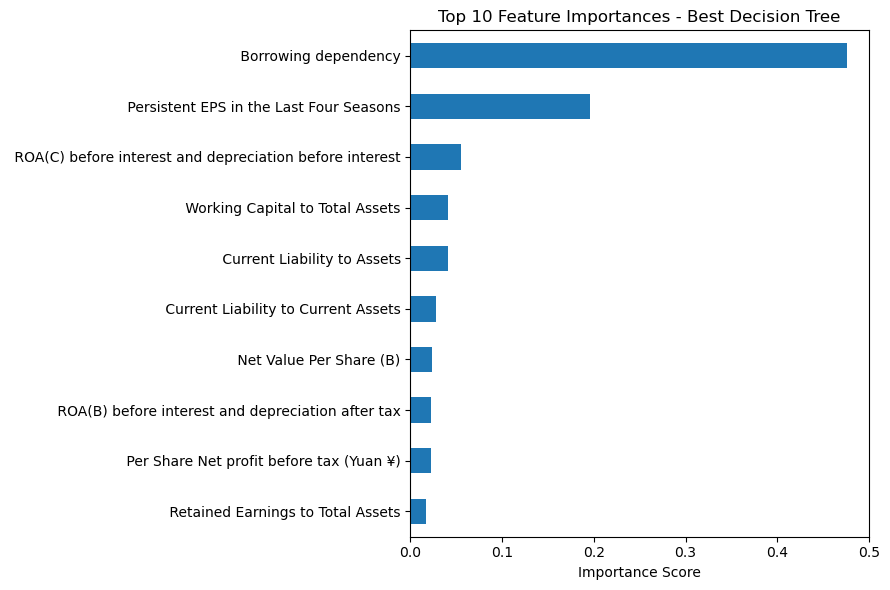

In [88]:
# Visualize top 10 feature importances
plt.figure(figsize=(9,6))
importance.head(10).sort_values().plot(kind='barh')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances - Best Decision Tree')
plt.tight_layout()
plt.show()

## 14. Decision Tree Structure Visualisation

A shallow tree is plotted for readability.  
This shows one of the main strengths of decision trees: **interpretability**.


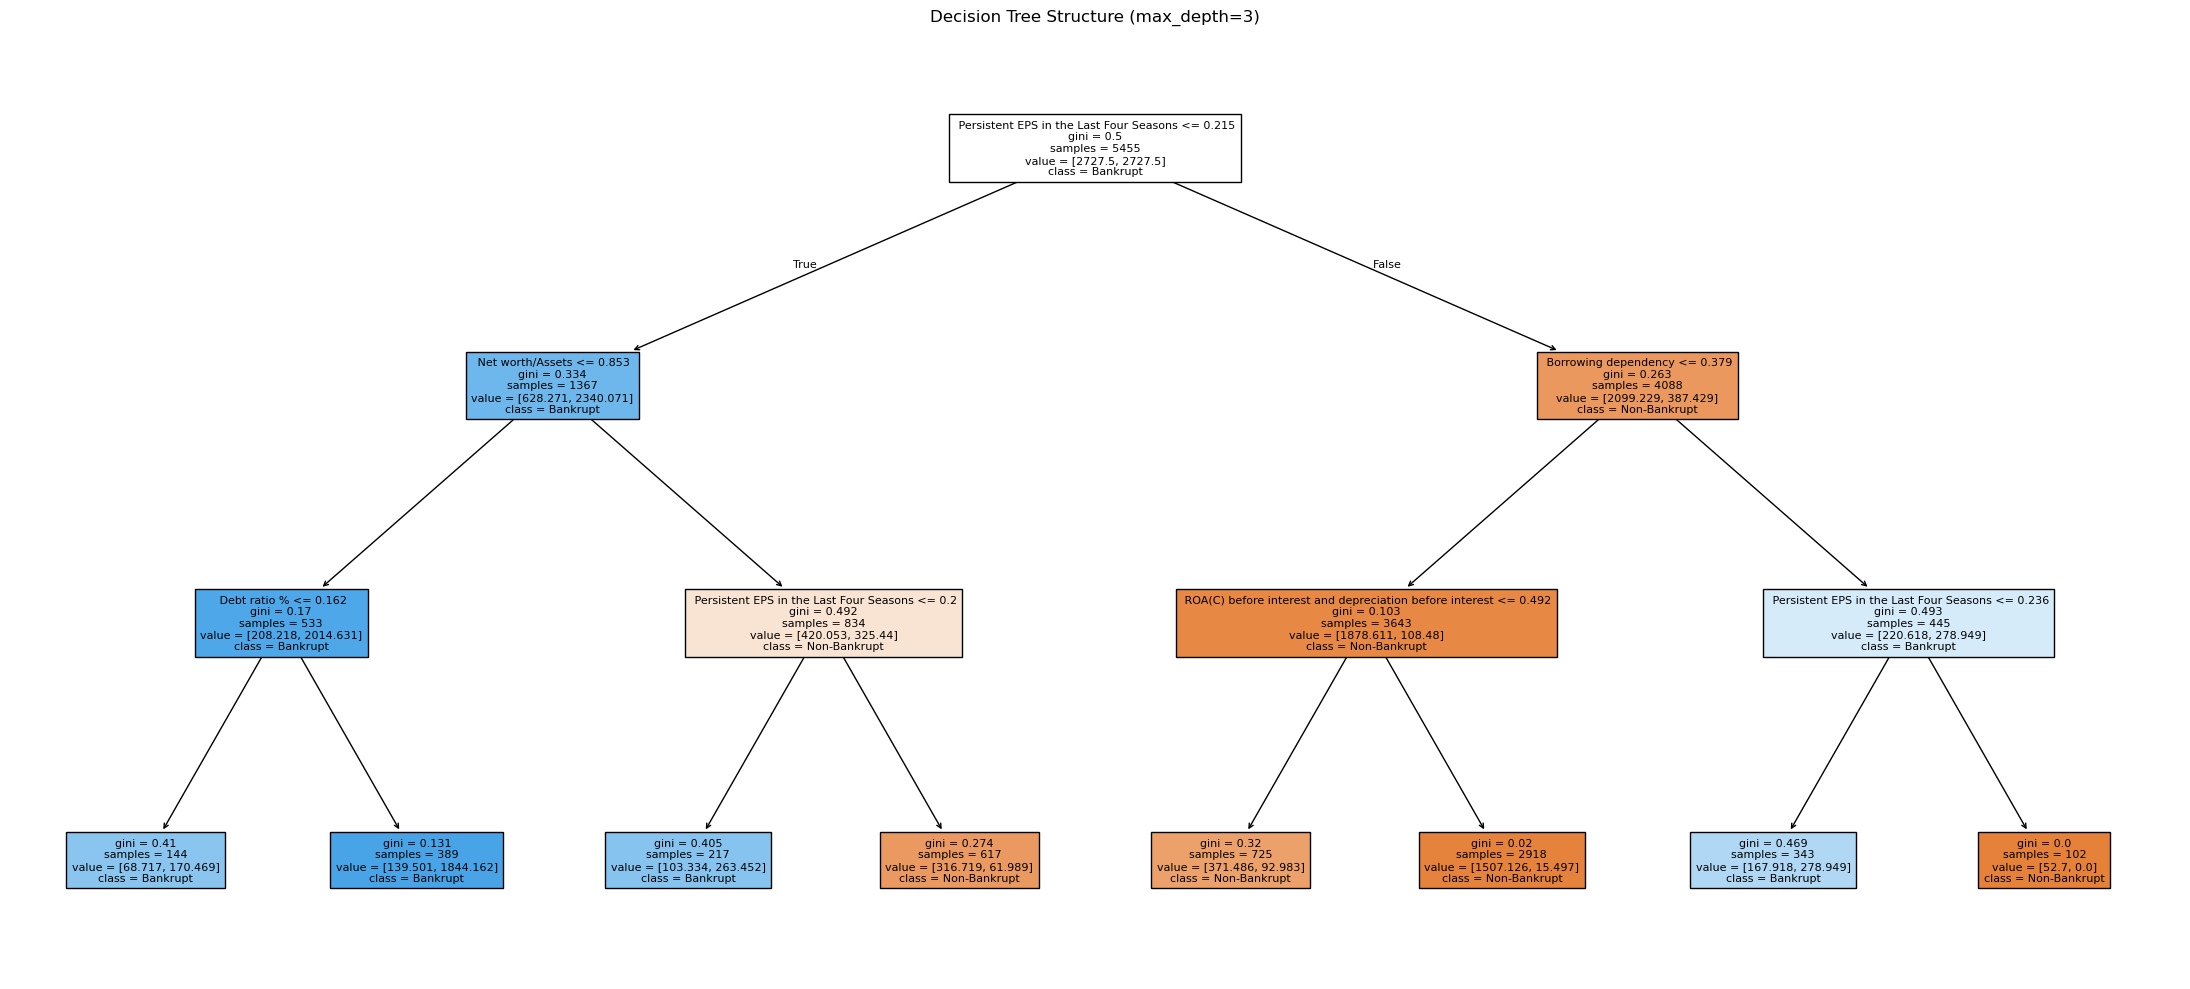

In [89]:
# Visualize the structure of a small pruned tree for interpretability
small_dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
small_dt.fit(X_train_sel, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    small_dt,
    feature_names=selected_feature_names,
    class_names=['Non-Bankrupt', 'Bankrupt'],
    filled=True,
    fontsize=8
)
plt.title('Decision Tree Structure (max_depth=3)')
plt.tight_layout()
plt.show()

## 15. Final Results Summary and Discussion

### Key findings
- The dataset is **strongly imbalanced**, so accuracy alone is not a reliable indicator of quality.
- A corrected pipeline with **feature selection inside training**, together with **resampling or class weighting**, gives a more trustworthy workflow.
- The final tuned tree improves minority-class detection compared with a simple unrestricted baseline.
- The model is **interpretable**, and feature importance plus tree visualisation make the decision process easier to explain.

### Limitations
- Precision may still remain modest when recall is improved.
- Decision Trees are sensitive to small changes in data and can overfit.
- SMOTE/ADASYN may generate synthetic minority points that do not perfectly reflect real companies.

### Future work
- compare with **Random Forest** and **XGBoost**
- test **threshold tuning**
- test **hybrid imbalance methods** such as SMOTEENN or SMOTETomek
- compare against Logistic Regression, KNN, and SVM using the same train/test split and evaluation metrics
